This file contains testing of various techniques for thresholding to find the best option for anonymisation via filtering + thresholding. Blob analysis is also explored in this file.

In [6]:
import tensorflow as tf

In [8]:
import pandas as pd

In [10]:
import matplotlib.pyplot as plt

In [19]:
import numpy as np

In [9]:
import cv2 as cv

In [11]:
x = cv.imread("seq_000009.jpg", cv.IMREAD_GRAYSCALE)

In [15]:
x

array([[  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       ...,
       [129, 129, 129, ..., 171, 175, 177],
       [128, 128, 128, ..., 157, 161, 162],
       [131, 131, 130, ..., 146, 144, 142]], shape=(480, 640), dtype=uint8)

In [13]:
import PIL as pil
from PIL import ImageFilter
from PIL import ImageEnhance

In [16]:
%matplotlib inline

In [25]:
img = pil.Image.open("seq_000009.jpg")
img = pil.ImageOps.grayscale(img)
img = np.asarray(img)

In [29]:
img/255

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.50588235, 0.50588235, 0.50588235, ..., 0.67058824, 0.68627451,
        0.69411765],
       [0.50196078, 0.50196078, 0.50196078, ..., 0.61568627, 0.63137255,
        0.63529412],
       [0.51372549, 0.51372549, 0.50980392, ..., 0.57254902, 0.56470588,
        0.55686275]], shape=(480, 640))

In [742]:

enhancer2 = ImageEnhance.Brightness(img)
img1 = enhancer2.enhance(1.1)

enhancer = ImageEnhance.Contrast(img1)
img2 = enhancer.enhance(0.9)

In [744]:

img3 = img2.filter(ImageFilter.GaussianBlur(1))
img3.save("IMG2.jpg")

In [746]:
img5 = cv.imread("IMG2.jpg", cv.IMREAD_GRAYSCALE)
img6 = cv.imread("seq_000009.jpg", cv.IMREAD_GRAYSCALE)

In [566]:
print(img5)

[[ 6  6  6 ...  6  6  6]
 [ 6  6  6 ...  6  6  6]
 [ 6  6  6 ...  6  6  6]
 ...
 [62 62 62 ... 82 84 85]
 [63 63 63 ... 76 78 79]
 [63 63 63 ... 70 71 72]]


In [610]:
if img is None:
    print("boo")
else:
    print("yay")

yay


In [748]:
_, thresh_otsu = cv.threshold(img5, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
_, thresh_yum = cv.threshold(img6, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

In [750]:
cv.imwrite("IMG.jpg", thresh_otsu)
cv.imwrite("IMG6.jpg", thresh_yum)

True

In [14]:
img2= cv.imread("crowd.jpg", cv.IMREAD_GRAYSCALE)

In [15]:
_, thresh_ot = cv.threshold(img2, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

In [16]:
cv.imwrite("crowd2.jpg", thresh_ot)

True

In [546]:
params = cv.SimpleBlobDetector_Params()

In [752]:
params.filterByArea = True
params.filterByColor = True
params.blobColor = 0
params.minArea = 40
params.filterByCircularity = False
params.filterByConvexity = True
params.minConvexity = 0.15
params.filterByInertia = True
params.minInertiaRatio = 0.01
params.maxInertiaRatio = 0.75

In [754]:
detector = cv.SimpleBlobDetector_create(params)

In [756]:
keypoints = detector.detect(thresh_otsu)

In [758]:
out = cv.drawKeypoints(thresh_otsu, keypoints, np.array([]), (0, 0, 255), cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

In [760]:
cv.imwrite("crowd4.jpg", out)

True

In [764]:
from skimage import feature

In [876]:
blobs_doh = feature.blob_doh(thresh_otsu, max_sigma=20, threshold=0.02)

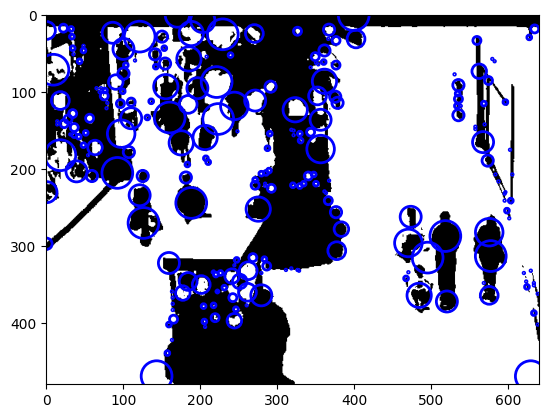

In [878]:
fig, ax = plt.subplots()
ax.imshow(thresh_otsu, cmap='gray')
for y, x, r in blobs_doh:
    c = plt.Circle((x, y), r, color='blue', linewidth=2, fill=False)
    ax.add_patch(c)
plt.show()

In [866]:
print(blobs_doh)

[[ 21.         326.           4.22222222]
 [209.         125.           7.44444444]
 [331.         483.           7.44444444]
 [244.         188.          23.55555556]
 [122.         323.          17.11111111]
 [211.         181.           7.44444444]
 [ 25.         229.          20.33333333]
 [224.         292.           4.22222222]
 [134.          56.           7.44444444]
 [127.          35.           4.22222222]
 [312.         467.          10.66666667]
 [272.         137.           4.22222222]
 [120.         202.          10.66666667]
 [ 63.         154.           7.44444444]
 [ 36.         268.           4.22222222]
 [163.         345.           4.22222222]
 [237.           2.           4.22222222]
 [ 19.         367.           7.44444444]
 [293.         127.          10.66666667]
 [194.         184.           4.22222222]
 [ 18.         184.           1.        ]
 [ 20.         407.           1.        ]
 [ 77.         530.           1.        ]
 [ 85.           2.           1.  

In [868]:
print(blobs_doh.length())

AttributeError: 'numpy.ndarray' object has no attribute 'length'

In [870]:
print(blobs_doh.shape[0])

59


In [880]:
print(keypoints)

(< cv2.KeyPoint 000002DB27C8CE40>, < cv2.KeyPoint 000002DB43076310>, < cv2.KeyPoint 000002DB43074780>, < cv2.KeyPoint 000002DB43075470>, < cv2.KeyPoint 000002DB43077450>, < cv2.KeyPoint 000002DB43075860>, < cv2.KeyPoint 000002DB430763D0>, < cv2.KeyPoint 000002DB43076640>, < cv2.KeyPoint 000002DB43075FE0>, < cv2.KeyPoint 000002DB430757D0>, < cv2.KeyPoint 000002DB430742D0>, < cv2.KeyPoint 000002DB430749C0>, < cv2.KeyPoint 000002DB43075B30>, < cv2.KeyPoint 000002DB43077F00>, < cv2.KeyPoint 000002DB430777B0>, < cv2.KeyPoint 000002DB43074F30>, < cv2.KeyPoint 000002DB430748D0>, < cv2.KeyPoint 000002DB430753B0>, < cv2.KeyPoint 000002DB43077660>, < cv2.KeyPoint 000002DB430773C0>, < cv2.KeyPoint 000002DB430758C0>, < cv2.KeyPoint 000002DB43074DE0>, < cv2.KeyPoint 000002DB43074C00>, < cv2.KeyPoint 000002DB43075E90>, < cv2.KeyPoint 000002DB43076CD0>)


In [886]:
print(len(keypoints))

25
